# Publisher comparison for CERC queries
To better understand where the large difference in publicaton lists between SciVal and OpenAlex for the three CERC queries, we look in more detail at the publishers of the papers listed in each query. 

In [157]:
# import libraries 

import pandas as pd
import numpy as np
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict
import matplotlib.pyplot as plt

# q1
q1_oa_raw = pd.read_csv('./cerc_results/query1.csv')
q1_sv_raw = pd.read_excel('./cerc_results/query1_SCIVAL.xlsx', sheet_name="rio results")

# q2
q2_oa_raw = pd.read_csv('./cerc_results/query2.csv')
q2_sv_raw = pd.read_excel('./cerc_results/query2_SCIVAL.xlsx', sheet_name="rio results")

# q3
q3_oa_raw = pd.read_csv('./cerc_results/query3.csv')
q3_sv_raw = pd.read_excel('./cerc_results/query3_SCIVAL.xlsx', sheet_name="rio results")

In [110]:
import os
print(os.path.abspath('./cerc_results/query1_SCIVAL.xlsx'))
print(os.getcwd())

c:\Users\tania\OneDrive - TM-IT Consulting Inc\Documents\juan\cerc_results\query1_SCIVAL.xlsx
c:\Users\tania\OneDrive - TM-IT Consulting Inc\Documents\juan


## Query 1

### OpenAlex

In [111]:
q1_oa_raw.columns

Index(['id', 'doi', 'title', 'display_name', 'relevance_score',
       'publication_year', 'publication_date', 'ids', 'language',
       'primary_location', 'type', 'indexed_in', 'open_access', 'authorships',
       'institutions', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci',
       'has_fulltext', 'cited_by_count', 'citation_normalized_percentile',
       'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext',
       'is_xpac', 'primary_topic', 'topics', 'keywords', 'concepts', 'mesh',
       'locations_count', 'locations', 'best_oa_location',
       'sustainable_development_goals', 'awards', 'funders', 'has_content',
       'content_urls', 'referenced_works_count', 'referenced_works',
       'related_works', 'abstract_inverted_index', 'counts_by_year',
       'updated_date', 'created_date'],
      dtype='object')

i want to keep id, doi, title, publication year, extract publisher name from primary location, extract is oa from open_access, fwci, cited_by_count only

In [112]:
q1_oa_clean = q1_oa_raw.copy()
q1_oa_clean['publisher_TEMP'] = q1_oa_clean['primary_location'].apply(lambda x: ast.literal_eval(x))
q1_oa_clean['journal_name'] = q1_oa_clean['publisher_TEMP'].apply(lambda x: x['raw_source_name'])
q1_oa_clean['publisher_TEMP2'] = q1_oa_clean['publisher_TEMP'].apply(lambda x: x['source'])
q1_oa_clean['publisher_name'] = q1_oa_clean['publisher_TEMP2'].apply(lambda x: x['host_organization_name'] if x is not None else None)
q1_oa_clean['oa_TEMP'] = q1_oa_clean['open_access'].apply(lambda x: ast.literal_eval(x))
q1_oa_clean['oa_status'] = q1_oa_clean['oa_TEMP'].apply(lambda x: x['is_oa'])
q1_oa_clean = q1_oa_clean[['id', 'doi', 'title', 'publication_year', 'journal_name', 'publisher_name', 'oa_status', 'fwci', 'cited_by_count']]

#q1_oa_clean

In [126]:
q1_oa_publisher_groups = pd.DataFrame(q1_oa_clean.groupby(['publisher_name']).count()['publication_year']).sort_values(by='publication_year', ascending=False).reset_index().rename(columns={'publication_year': 'publication_count'})
q1_oa_publisher_groups

,publisher_name,publication_count
0,Elsevier BV,97
1,Institute of Electrical and Electronics Engineers,85
2,Springer Science+Business Media,49
3,Wiley,49
4,Multidisciplinary Digital Publishing Institute,32
...,...,...
70,Surveillance Studies Network,1
71,Universidade Federal de São Paulo,1
72,The Company of Biologists,1
73,University of Huddersfield Press,1


In [139]:
q1_oa_big_pub = q1_oa_publisher_groups[q1_oa_publisher_groups['publication_count']>3]
q1_oa_big_pub.head()

,publisher_name,publication_count
0,Elsevier BV,97
1,Institute of Electrical and Electronics Engineers,85
2,Springer Science+Business Media,49
3,Wiley,49
4,Multidisciplinary Digital Publishing Institute,32


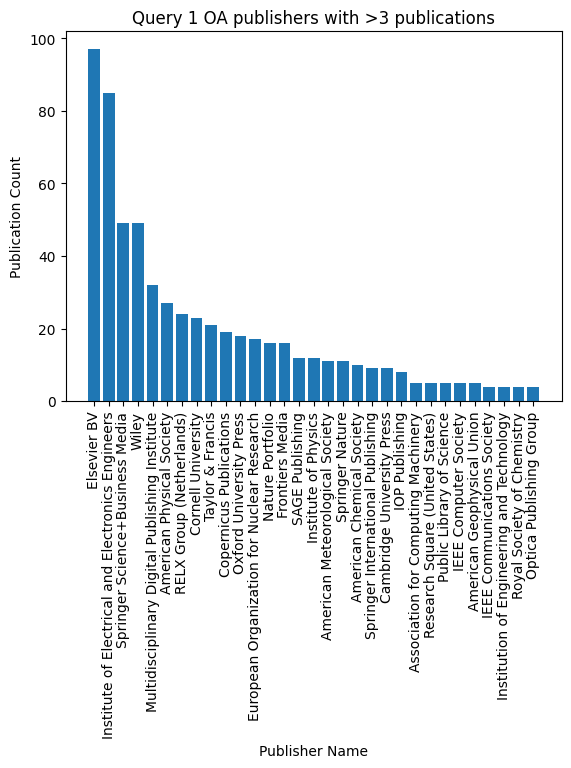

In [141]:
# Create the bar graph
plt.bar(q1_oa_big_pub['publisher_name'], q1_oa_big_pub['publication_count'])

# Add labels and a title
plt.xlabel("Publisher Name")
plt.ylabel("Publication Count")
plt.title("Query 1 OA publishers with >3 publications")
plt.xticks(range(len(q1_oa_big_pub['publisher_name'])), q1_oa_big_pub['publisher_name'], rotation='vertical') # or rotation=90

# Display the plot
plt.show()

### SciVal

In [118]:
q1_sv_raw.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN',
       'CODEN', 'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')

In [ ]:
test = q1_sv_raw.copy()
test['num_auths'] = test['Authors'].apply(lambda x: len(str.split(x, ';')))
#test

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID,num_auths
0,"Aghanim, N.; Akrami, Y.; Ashdown, M.; Aumont, ...","Aghanim, Nabila (6701390827); Akrami, Yashar (...",6701390827; 35387346400; 6603626885; 571954962...,Planck 2018 results: V. CMB power spectra and ...,2020,Astronomy and Astrophysics,641,NaN,A5,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85091948619,100
1,"Zhang, J.; Lei, J.; Xie, W.; Fang, Z.; Li, Y.;...","Zhang, Jiaqing (57201893177); Lei, Jie (366637...",57201893177; 36663710700; 56768656200; 3836126...,SuperYOLO: Super Resolution Assisted Object De...,2023,IEEE Transactions on Geoscience and Remote Sen...,61,NaN,5605415,NaN,...,IGRSD,NaN,English,IEEE Trans Geosci Remote Sens,Article,Final,NaN,Scopus,2-s2.0-85151518351,6
2,"Xiang, F.; Qin, Y.; Mo, K.; Xia, Y.; Zhu, H.; ...","Xiang, Fanbo (57219588888); Qin, Yuzhe (572195...",57219588888; 57219507801; 57201313394; 5721958...,Sapien: A simulated part-based interactive ENv...,2020,Proceedings of the IEEE Computer Society Confe...,NaN,NaN,9156706,11094,...,PIVRE,NaN,English,Proc IEEE Comput Soc Conf Comput Vision Patter...,Conference paper,Final,NaN,Scopus,2-s2.0-85094479575,14
3,"Szot, A.; Clegg, A.; Undersander, E.; Wijmans,...","Szot, Andrew (57223233772); Clegg, Alexander W...",57223233772; 56963583300; 57219481691; 5720131...,Habitat 2.0: Training Home Assistants to Rearr...,2021,Advances in Neural Information Processing Systems,1,NaN,NaN,251,...,NaN,NaN,English,Adv. neural inf. proces. syst.,Conference paper,Final,NaN,Scopus,2-s2.0-85121022702,21
4,"Shahabi, H.; Shirzadi, A.; Ghaderi, K.; Omidva...","Shahabi, Himan (57213611082); Shirzadi, Ataoll...",57213611082; 57209036611; 55575371100; 2592605...,Flood detection and susceptibility mapping usi...,2020,Remote Sensing,12,2,266,NaN,...,NaN,NaN,English,Remote Sens.,Article,Final,All Open Access; Gold Open Access; Green Accep...,Scopus,2-s2.0-85081087241,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,"Amini, J.; Moallem, M.","Amini, Jalal (57200975364); Moallem, Mehrdad (...",57200975364; 35609219200,Logic-based space-vector modulation for neutra...,2020,IET Power Electronics,13,19,NaN,4462,...,NaN,NaN,English,IET Power Electron.,Article,Final,NaN,Scopus,2-s2.0-85102394687,2
946,"Rosychuk, R.J.; Bachman, J.W.N.; Chen, A.; Hu,...","Rosychuk, Rhonda Jean (7003299198); Bachman, J...",7003299198; 57220203033; 57219394662; 35229913300,Handling coarsened age information in the anal...,2020,BMC Medical Research Methodology,20,1,297,NaN,...,NaN,33287720.0,English,BMC Med. Res. Methodol.,Article,Final,All Open Access; Gold Open Access; Green Accep...,Scopus,2-s2.0-85097307183,4
947,"Hynes, C.G.; Vaughan, R.G.","Hynes, Christopher G. (14009855500); Vaughan, ...",14009855500; 7201481830,Detection of Electric and Magnetic Dipole Mome...,2020,2020 IEEE International Symposium on Antennas ...,NaN,NaN,9330408,247,...,NaN,NaN,English,IEEE Int. Symp. Antennas Propag. North Am. Rad...,Conference paper,Final,NaN,Scopus,2-s2.0-85101641412,2
948,"Meyer, K.E.; Ding, Y.; Li, J.; Zhang, H.","Meyer, Klaus E. (7401793822); Ding, Yuan (7404...",7401793822; 7404136394; 57216939987; 53873458900,Overcoming distrust: How state-owned enterpris...,2020,Multinational Enterprises and Emerging Economies,NaN,NaN,NaN,291,...,NaN,NaN,English,Multinational Enterprises and Emerg. Economies,Book chapter,Final,NaN,Scopus,2-s2.0-85139711973,4


In [188]:
test['num_auths'].unique()

array([100,   6,  14,  21,  17,   7,   8,  27,   9,  24,  29,  10,   4,
         3,  54,  25,   5,  11,   2,   1,  12,  32,  59,  20,  48,  15,
        18,  13,  36,  19,  28,  16,  44,  22,  46,  55,  45,  78,  77])

In [189]:
test[test['num_auths'] == 100]

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID,num_auths
0,"Aghanim, N.; Akrami, Y.; Ashdown, M.; Aumont, ...","Aghanim, Nabila (6701390827); Akrami, Yashar (...",6701390827; 35387346400; 6603626885; 571954962...,Planck 2018 results: V. CMB power spectra and ...,2020,Astronomy and Astrophysics,641,NaN,A5,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85091948619,100
7,"Aad, G.; Abbott, B.; Abbott, D.C.; Abed Abud, ...","Aad, Georges (26326745400); Abbott, Brad K. (3...",26326745400; 35226946900; 57208306618; 5720890...,Jet energy scale and resolution measured in pr...,2021,European Physical Journal C,81,8,689,NaN,...,NaN,NaN,English,Eur. Phys. J. C,Article,Final,All Open Access; Gold Open Access; Green Accep...,Scopus,2-s2.0-85112476443,100
8,"Aad, G.; Abbott, B.; Abbott, D.C.; Abed Abud, ...","Aad, Georges (26326745400); Abbott, Brad K. (3...",26326745400; 35226946900; 57208306618; 5720890...,Performance of the ATLAS muon triggers in Run 2,2020,Journal of Instrumentation,15,9,P09015,NaN,...,NaN,NaN,English,J. Instrum.,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85096387405,100
12,"Akrami, Y.; Ashdown, M.; Aumont, J.; Baccigalu...","Akrami, Yashar (35387346400); Ashdown, Mark A....",35387346400; 6603626885; 57195496279; 57220414...,Planck 2018 results: IV. Diffuse component sep...,2020,Astronomy and Astrophysics,641,NaN,A4,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Bronze Open Access; Green Acc...,Scopus,2-s2.0-85084221331,100
14,"Akrami, Y.; Andersen, K.J.; Ashdown, M.; Bacci...","Akrami, Yashar (35387346400); Andersen, K. J. ...",35387346400; 57219619672; 6603626885; 57220414...,Planck intermediate results: LVII. Joint Planc...,2020,Astronomy and Astrophysics,643,NaN,A42,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Bronze Open Access; Green Acc...,Scopus,2-s2.0-85096100312,100
17,"Aad, G.; Abbott, B.; Abbott, D.C.; Abed Abud, ...","Aad, Georges (26326745400); Abbott, Brad K. (3...",26326745400; 35226946900; 57208306618; 5720890...,Dijet Resonance Search with Weak Supervision U...,2020,Physical Review Letters,125,13,131801,NaN,...,PRLTA,33034503.0,English,Phys Rev Lett,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85092801738,100
24,"Akrami, Y.; Ashdown, M.; Aumont, J.; Baccigalu...","Akrami, Yashar (35387346400); Ashdown, Mark A....",35387346400; 6603626885; 57195496279; 57220414...,Planck 2018 results: XI. Polarized dust foregr...,2020,Astronomy and Astrophysics,641,NaN,A11,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85092300272,100
29,"Aghanim, N.; Akrami, Y.; Alves, M.I.R.; Ashdow...","Aghanim, Nabila (6701390827); Akrami, Yashar (...",6701390827; 35387346400; 57213857548; 66036268...,Planck 2018 results: XII. Galactic astrophysic...,2020,Astronomy and Astrophysics,641,NaN,A12,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85091892569,100
30,"Aghanim, N.; Akrami, Y.; Ashdown, M.; Aumont, ...","Aghanim, Nabila (6701390827); Akrami, Yashar (...",6701390827; 35387346400; 6603626885; 571954962...,Planck 2018 results: III. High frequency instr...,2020,Astronomy and Astrophysics,641,NaN,A3,NaN,...,AAEJA,NaN,English,Astron. Astrophys.,Article,Final,All Open Access; Green Accepted Open Access; G...,Scopus,2-s2.0-85091901452,100
33,"Aad, G.; Abbott, B.; Abbott, D.C.; Abed Abud, ...","Aad, Georges (26326745400); Abbott, Brad K. (3...",26326745400; 35226946900; 57208306618; 5720890...,Observation of an Excess of Dicharmonium Event...,2023,Physical Review Letters,131,15,151902,NaN,...,PRLTA,37897770.0,E

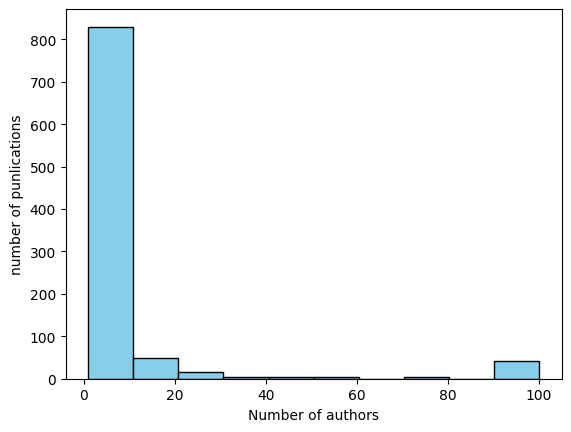

In [187]:
plt.hist(test['num_auths'], color='skyblue', edgecolor='black')
plt.xlabel('Number of authors')
plt.ylabel('number of punlications')
plt.show()

i want to keep id, doi, title, publication year, extract publisher name from primary location, extract is oa from open_access, ~~fwci~~, cited_by_count only

In [128]:
q1_sv_clean = q1_sv_raw.copy()
q1_sv_clean = q1_sv_clean[['EID', 'DOI', 'Title', 'Year', 'Publisher', 'Source title', 'Open Access', 'Cited by']]

#q1_sv_clean

In [129]:
q1_sv_publisher_groups = pd.DataFrame(q1_sv_clean.groupby(['Publisher']).count()['Year']).sort_values(by='Year', ascending=False).reset_index().rename(columns={'Year': 'publication_count'})
q1_sv_publisher_groups

,Publisher,publication_count
0,Institute of Electrical and Electronics Engine...,192
1,Elsevier B.V.,52
2,Elsevier Ltd,47
3,John Wiley and Sons Inc,37
4,Springer Science and Business Media Deutschlan...,36
...,...,...
170,Web Portal Ubiquity Press,1
171,Wiley-Blackwell,1
172,Wiley-VCH Verlag,1
173,World Scientific,1


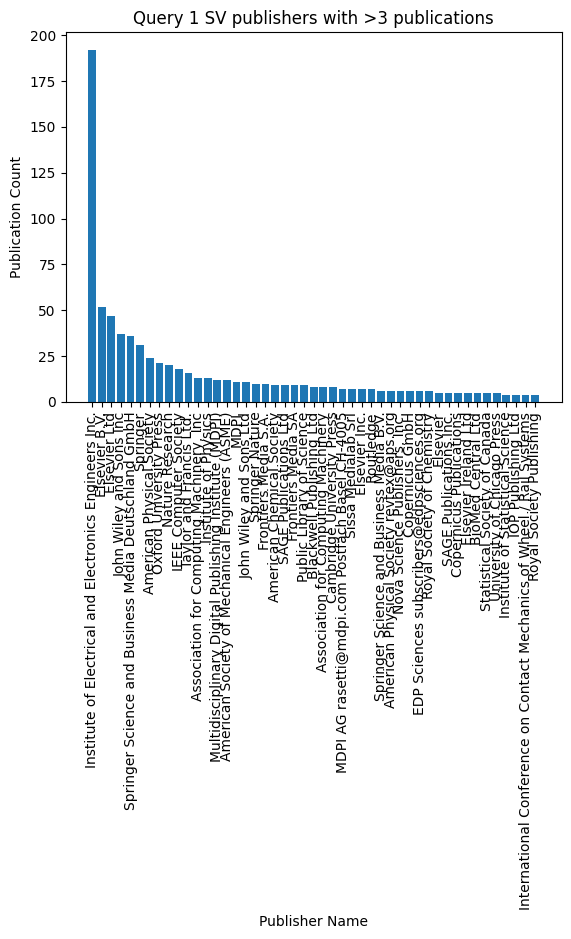

In [145]:
q1_sv_big_pub = q1_sv_publisher_groups[q1_sv_publisher_groups['publication_count']>3]
#q1_oa_big_pub.head()

# Create the bar graph
plt.bar(q1_sv_big_pub['Publisher'], q1_sv_big_pub['publication_count'])

plt.xlabel("Publisher Name")
plt.ylabel("Publication Count")
plt.title("Query 1 SV publishers with >3 publications")
plt.xticks(range(len(q1_sv_big_pub['Publisher'])), q1_sv_big_pub['Publisher'], rotation='vertical') 

plt.show()

SciVal somehow has way more distinct publishers - this is partally due to the fact that their name standardization is worse than in OpenAlex (surprisingly?). Also interestingly, SciVal has way more publications under IEEE than OpenAlex. My suspicion is that the big publications arent being caught by OpenAlex for some reason, but they are by SciVal (as per our investigation of some specific publications earlier). Will run the same for Query 2 and 3 and start digging into authors in more detail. 

## Query 2

### OpenAlex

i want to keep id, doi, title, publication year, extract publisher name from primary location, extract is oa from open_access, fwci, cited_by_count only

In [ ]:
q2_oa_clean = q2_oa_raw.copy()
q2_oa_clean['publisher_TEMP'] = q2_oa_clean['primary_location'].apply(lambda x: ast.literal_eval(x))
q2_oa_clean['journal_name'] = q2_oa_clean['publisher_TEMP'].apply(lambda x: x['raw_source_name'])
q2_oa_clean['publisher_TEMP2'] = q2_oa_clean['publisher_TEMP'].apply(lambda x: x['source'])
q2_oa_clean['publisher_name'] = q2_oa_clean['publisher_TEMP2'].apply(lambda x: x['host_organization_name'] if x is not None else None)
q2_oa_clean['oa_TEMP'] = q2_oa_clean['open_access'].apply(lambda x: ast.literal_eval(x))
q2_oa_clean['oa_status'] = q2_oa_clean['oa_TEMP'].apply(lambda x: x['is_oa'])
q2_oa_clean = q2_oa_clean[['id', 'doi', 'title', 'publication_year', 'journal_name', 'publisher_name', 'oa_status', 'fwci', 'cited_by_count']]

#q2_oa_clean

,id,doi,title,publication_year,journal_name,publisher_name,oa_status,fwci,cited_by_count
0,https://openalex.org/W3197182136,https://doi.org/10.1088/2631-8695/ac2353,A review of primary technologies of thin-film ...,2021,Engineering Research Express,IOP Publishing,True,8.823900,124
1,https://openalex.org/W3097814634,https://doi.org/10.1038/s41598-020-75393-y,Material properties and structure of natural g...,2020,Scientific Reports,Nature Portfolio,True,2.559200,82
2,https://openalex.org/W4311425960,https://doi.org/10.1016/j.addma.2022.103357,Review of transfer learning in modeling additi...,2022,Additive Manufacturing,Elsevier BV,False,8.357900,67
3,https://openalex.org/W4220703584,https://doi.org/10.1016/j.isci.2022.104119,A 3D-printed neuromorphic humanoid hand for gr...,2022,iScience,Cell Press,True,2.653400,32
4,https://openalex.org/W4210529131,https://doi.org/10.1038/s41528-022-00139-x,3D printed leech-inspired origami dry electrod...,2022,npj Flexible Electronics,Nature Portfolio,True,3.522300,44
...,...,...,...,...,...,...,...,...,...
193,https://openalex.org/W4285398133,https://doi.org/10.1149/ma2022-01351418mtgabs,Fe- and Co-Containing Nitrogen-Doped Nanocarbo...,2022,ECS Meeting Abstracts,Institute of Physics,False,0.000000,0
194,https://openalex.org/W4393072836,https://doi.org/10.1111/sjtg.12539,Guest Editorial: The social life of Chinese in...,2024,Singapore Journal of Tropical Geography,Wiley,True,11.940961,3
195,https://openalex.org/W4391662786,https://doi.org/10.1149/ma2023-02381818mtgabs,Impact of Missing Cathode Catalyst Layer Areas...,2023,ECS Meeting Abstracts,Institute of Physics,False,0.000000,0
196,https://openalex.org/W3114762970,https://doi.org/10.1149/ma2020-02352257mtgabs,Exploring Component Interactions during Mechan...,2020,ECS Meeting Abstracts,Institute of Physics,False,0.000000,0


In [161]:
q2_oa_publisher_groups = pd.DataFrame(q2_oa_clean.groupby(['publisher_name']).count()['publication_year']).sort_values(by='publication_year', ascending=False).reset_index().rename(columns={'publication_year': 'publication_count'})
q2_oa_publisher_groups

,publisher_name,publication_count
0,Elsevier BV,49
1,Institute of Physics,22
2,Wiley,16
3,American Chemical Society,15
4,Royal Society of Chemistry,9
5,Multidisciplinary Digital Publishing Institute,7
6,American Physical Society,7
7,Nature Portfolio,7
8,IOP Publishing,5
9,American Institute of Physics,5


In [162]:
q2_oa_big_pub = q2_oa_publisher_groups[q2_oa_publisher_groups['publication_count']>3]
q2_oa_big_pub.head()

,publisher_name,publication_count
0,Elsevier BV,49
1,Institute of Physics,22
2,Wiley,16
3,American Chemical Society,15
4,Royal Society of Chemistry,9


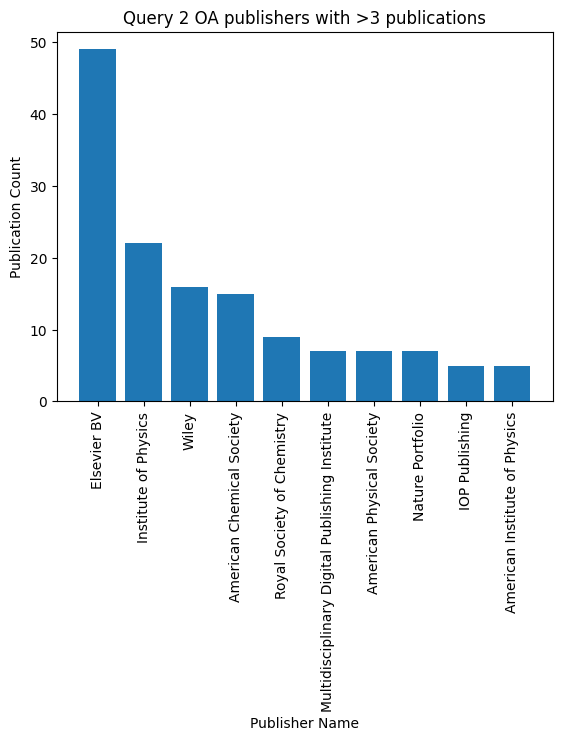

In [163]:
# Create the bar graph
plt.bar(q2_oa_big_pub['publisher_name'], q2_oa_big_pub['publication_count'])

# Add labels and a title
plt.xlabel("Publisher Name")
plt.ylabel("Publication Count")
plt.title("Query 2 OA publishers with >3 publications")
plt.xticks(range(len(q2_oa_big_pub['publisher_name'])), q2_oa_big_pub['publisher_name'], rotation='vertical') # or rotation=90

# Display the plot
plt.show()

### SciVal

In [164]:
q2_sv_raw.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN',
       'CODEN', 'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')

i want to keep id, doi, title, publication year, extract publisher name from primary location, extract is oa from open_access, ~~fwci~~, cited_by_count only

In [169]:
q2_sv_clean = q2_sv_raw.copy()
q2_sv_clean = q2_sv_clean[['EID', 'DOI', 'Title', 'Year', 'Publisher', 'Source title', 'Open Access', 'Cited by']]

#q2_sv_clean

In [170]:
q2_sv_publisher_groups = pd.DataFrame(q2_sv_clean.groupby(['Publisher']).count()['Year']).sort_values(by='Year', ascending=False).reset_index().rename(columns={'Year': 'publication_count'})
q2_sv_publisher_groups

,Publisher,publication_count
0,Elsevier Ltd,41
1,Elsevier B.V.,27
2,John Wiley and Sons Inc,24
3,Institute of Electrical and Electronics Engine...,20
4,American Chemical Society,17
...,...,...
78,University of Toronto Press,1
79,VLDB Endowment,1
80,Wiley-VCH Verlag,1
81,Wiley-VCH Verlag info@wiley-vch.de,1


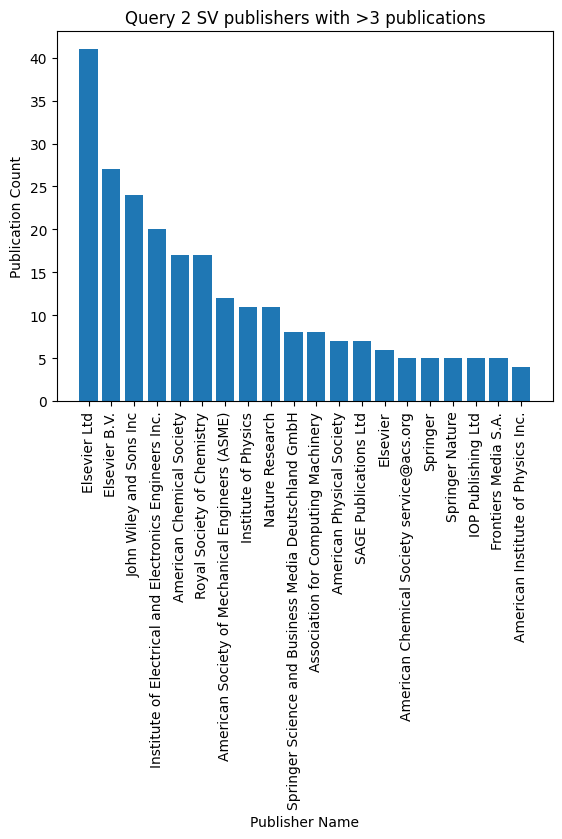

In [172]:
q2_sv_big_pub = q2_sv_publisher_groups[q2_sv_publisher_groups['publication_count']>3]
#q2_oa_big_pub.head()

# Create the bar graph
plt.bar(q2_sv_big_pub['Publisher'], q2_sv_big_pub['publication_count'])

plt.xlabel("Publisher Name")
plt.ylabel("Publication Count")
plt.title("Query 2 SV publishers with >3 publications")
plt.xticks(range(len(q2_sv_big_pub['Publisher'])), q2_sv_big_pub['Publisher'], rotation='vertical') 

plt.show()

Again SV has more publishers, due to bad name standardization 

## Query 3

### OpenAlex

i want to keep id, doi, title, publication year, extract publisher name from primary location, extract is oa from open_access, fwci, cited_by_count only

In [173]:
q3_oa_clean = q3_oa_raw.copy()
q3_oa_clean['publisher_TEMP'] = q3_oa_clean['primary_location'].apply(lambda x: ast.literal_eval(x))
q3_oa_clean['journal_name'] = q3_oa_clean['publisher_TEMP'].apply(lambda x: x['raw_source_name'])
q3_oa_clean['publisher_TEMP2'] = q3_oa_clean['publisher_TEMP'].apply(lambda x: x['source'])
q3_oa_clean['publisher_name'] = q3_oa_clean['publisher_TEMP2'].apply(lambda x: x['host_organization_name'] if x is not None else None)
q3_oa_clean['oa_TEMP'] = q3_oa_clean['open_access'].apply(lambda x: ast.literal_eval(x))
q3_oa_clean['oa_status'] = q3_oa_clean['oa_TEMP'].apply(lambda x: x['is_oa'])
q3_oa_clean = q3_oa_clean[['id', 'doi', 'title', 'publication_year', 'journal_name', 'publisher_name', 'oa_status', 'fwci', 'cited_by_count']]

#q3_oa_clean

In [174]:
q3_oa_publisher_groups = pd.DataFrame(q3_oa_clean.groupby(['publisher_name']).count()['publication_year']).sort_values(by='publication_year', ascending=False).reset_index().rename(columns={'publication_year': 'publication_count'})
q3_oa_publisher_groups

,publisher_name,publication_count
0,Elsevier BV,73
1,Taylor & Francis,64
2,Wiley,48
3,SAGE Publishing,37
4,University of Oxford,33
...,...,...
90,University of California Press,1
91,University of Winnipeg,1
92,University of Toronto Press,1
93,Wellcome,1


In [175]:
q3_oa_big_pub = q3_oa_publisher_groups[q3_oa_publisher_groups['publication_count']>3]
q3_oa_big_pub.head()

,publisher_name,publication_count
0,Elsevier BV,73
1,Taylor & Francis,64
2,Wiley,48
3,SAGE Publishing,37
4,University of Oxford,33


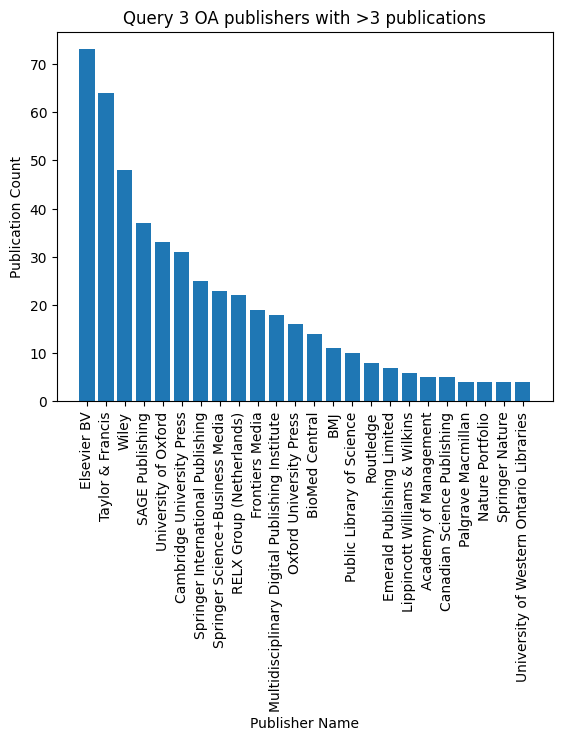

In [177]:
# Create the bar graph
plt.bar(q3_oa_big_pub['publisher_name'], q3_oa_big_pub['publication_count'])

# Add labels and a title
plt.xlabel("Publisher Name")
plt.ylabel("Publication Count")
plt.title("Query 3 OA publishers with >3 publications")
plt.xticks(range(len(q3_oa_big_pub['publisher_name'])), q3_oa_big_pub['publisher_name'], rotation='vertical') # or rotation=90

# Display the plot
plt.show()

### SciVal

In [178]:
q3_sv_raw.columns

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN',
       'CODEN', 'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')

i want to keep id, doi, title, publication year, extract publisher name from primary location, extract is oa from open_access, ~~fwci~~, cited_by_count only

In [181]:
q3_sv_clean = q3_sv_raw.copy()
q3_sv_clean = q3_sv_clean[['EID', 'DOI', 'Title', 'Year', 'Publisher', 'Source title', 'Open Access', 'Cited by']]

#q3_sv_clean

In [182]:
q3_sv_publisher_groups = pd.DataFrame(q3_sv_clean.groupby(['Publisher']).count()['Year']).sort_values(by='Year', ascending=False).reset_index().rename(columns={'Year': 'publication_count'})
q3_sv_publisher_groups

,Publisher,publication_count
0,Elsevier Ltd,59
1,Routledge,56
2,John Wiley and Sons Inc,37
3,BioMed Central Ltd,33
4,Taylor and Francis,30
...,...,...
155,Volcanica,1
156,Weston Medical Publishing,1
157,WellBeing International,1
158,Walter de Gruyter GmbH,1


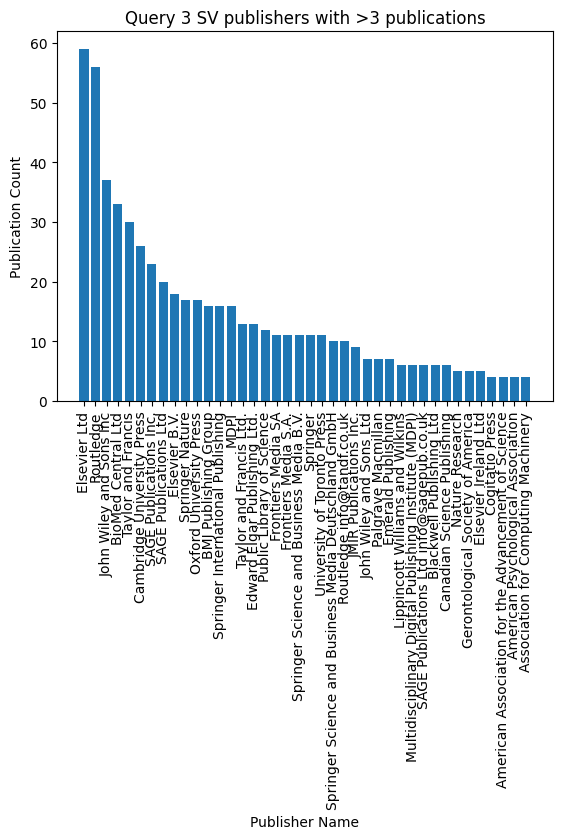

In [183]:
q3_sv_big_pub = q3_sv_publisher_groups[q3_sv_publisher_groups['publication_count']>3]
#q3_sv_big_pub.head()

# Create the bar graph
plt.bar(q3_sv_big_pub['Publisher'], q3_sv_big_pub['publication_count'])

plt.xlabel("Publisher Name")
plt.ylabel("Publication Count")
plt.title("Query 3 SV publishers with >3 publications")
plt.xticks(range(len(q3_sv_big_pub['Publisher'])), q3_sv_big_pub['Publisher'], rotation='vertical') 

plt.show()

Again SV has more publishers, due to bad name standardization 